### Step 1: problem statement and collect data

- Problem statement: using six features to predict charges. 
- Regression problem because of charges. In other words, it is not discrete categories.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [2]:
url = 'https://raw.githubusercontent.com/liaochunyang/PIC16/refs/heads/main/PIC16A/data/insurance.csv'
df = pd.read_csv(url)
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


### Step 2: Data analysis

- Observation: I should use 'age', 'smoker', 'bmi+smoker'. 

### Step 3: Data transformation/data clearning

- Transform categroical data to numerical data. Two methods: one-hot encoding and label encoding. I decide to use label encoding because it is easy for me to create new features.

- Create a new feature: 'bmi' * 'smoker'. 

In [4]:
def one_hot(df, cols):
    """
    df: pandas DataFrame
    param: cols a list of columns to encode 
    return a DataFrame with one-hot encoding
    """
    for each in cols:
        dummies = pd.get_dummies(df[each], prefix=each, drop_first=False)
        df = pd.concat([df, dummies], axis=1)
    return df


def label(df, cols):
    
    for each in cols:
        
        #label_encoder = LabelEncoder()
        #dummies = label_encoder.fit_transform(df[each])
        #dummies = pd.DataFrame(dummies, columns=[each])
        #df = pd.concat([df, dummies], axis=1)
        
        label_encoder = LabelEncoder()
        df[each] = label_encoder.fit_transform(df[each])
        
    return df

In [5]:
# one-hot encoding
cat_all = ['sex', 'smoker', 'region']
df_medical = one_hot(df, cat_all)

# label encoding
df_med = label(df, cat_all)


### Step 4: Model construction.

- Linear regression model. 

- Train test split. Training data is used for model training and test data is used for comparison/performance analysis.

### Step 5: Model analysis.

- How can you measure the performance? How to compare different models.
- Make your results robust.

In [12]:
def comput_test_error(X, y):
    """
    Compute test error. 
    Args:
    X: numpy array containing all features.
    y: target. A numpy array.
    Returns:
    mse: mean squared error.
    rel_se: relative squared error.
    """
    # train test split: each time you will randomly select training and test samples.
    X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2)
    
    # model initialization
    model = LinearRegression()
    # trianing this model
    model.fit(X_train, y_train)
    
    # prediction 
    y_pred = model.predict(X_test)
    # compute the test mse: mean squared error
    mse = np.sum(  (y_test - y_pred)**2  ) / np.size(y_test)
    
    # compute the relative squared error
    rel_se = np.sum(  (y_test - y_pred)**2  ) / np.sum( y_test**2 )
    
    return mse, rel_se
    

In [13]:
# Model 1: three features to predict "age", "smoker", "bmi"*"smoker"
df_med['A'] = df_med['bmi'] * df_med['smoker']
df_med1 = df_med.drop(columns = ['sex', 'children', 'region', 'bmi'])

# Dataset X, y
X = df_med1[['age','smoker','A']].to_numpy()
y = df_med1['charges'].to_numpy()

mse_model1, rel_se_model1 = comput_test_error(X, y)
print(mse_model1)    # it is huge because of the scale of your targets.
print(rel_se_model1)

24385584.121316567
0.07444796239337477


Comments: I want to eliminate the effect of scales.

- Method 1: relative error. Added in the function.

- Method 2: rescale my targets.

In [14]:
# the second method: scale y

# Dataset X, y
X = df_med1[['age','smoker','A']].to_numpy()
y = df_med1['charges'].to_numpy()

# scale my targets: scale y to [0,1]
y_scaled = ( y - np.min(y) ) / (np.max(y) - np.min(y))

# compute training errors:
mse_model2, rel_se_model2 = comput_test_error(X, y_scaled)
print(mse_model2)   
print(rel_se_model2)
# mse is small because you rescale your targets.
# relative error remains the same. 

# Conclusion: the model has 7% of the predicted error.

0.00595102448545173
0.0779978775057687


# Compare with other models

- how to compare: we look at test metrics.

- I want to claim that data analysis is helpful.

In [17]:
# Model 3
X = df_med[['age','sex','bmi','children','smoker','region']].to_numpy()
y = df_med['charges']

mse_model3, rel_se_model3 = comput_test_error(X, y)
print(mse_model1, mse_model3)   
print(rel_se_model1, rel_se_model3)

# when you compare models:
# 1. you should use test errors. 
# 2. you should use the same metrics. For example, mse vs mse, and rel_se vs rel_se. MSE VS Rel_se is not correct.

24385584.121316567 36595313.30289422
0.07444796239337477 0.13186061815884906


Even if you use more features to predict, it does not mean that you have better performance.

## Train test split

Observation: Since train-test split is random, we will see different results each time.

Usually, we want to eliminate the effect of randomness. To do that, we can repeat the experiments multiplease times and then compute the average.


In [20]:
# Model 1: three features to predict "age", "smoker", "bmi"*"smoker"
df_med['A'] = df_med['bmi'] * df_med['smoker']
df_med1 = df_med.drop(columns = ['sex', 'children', 'region', 'bmi'])

# Dataset X, y
X = df_med1[['age','smoker','A']].to_numpy()
y = df_med1['charges'].to_numpy()

mse_model1, rel_se_model1 = comput_test_error(X, y)

# Model 2: use all features to predict 
X = df_med[['age','sex','bmi','children','smoker','region']].to_numpy()
y = df_med['charges']

mse_model2, rel_se_model2 = comput_test_error(X, y)

# present errors
print(mse_model1, mse_model2)   
print(rel_se_model1, rel_se_model2)

21075630.487495195 32618500.81703329
0.07041196454820428 0.09489866933473094


In [21]:
# Data transformation for model 1
# Model 1: three features to predict "age", "smoker", "bmi"*"smoker"
df_med['A'] = df_med['bmi'] * df_med['smoker']
df_med1 = df_med.drop(columns = ['sex', 'children', 'region', 'bmi'])

# Dataset X1, y1
X1 = df_med1[['age','smoker','A']].to_numpy()
y1 = df_med1['charges'].to_numpy()

# Data transformation for model 2
X2 = df_med[['age','sex','bmi','children','smoker','region']].to_numpy()
y2 = df_med['charges']

# Compute average:

T = 20     # number of trials

# space to save relative errors
error_1 = np.zeros(T)   
error_2 = np.zeros(T)

for i in range(T):
    
    # compute errors for model 1
    mse1, rel_se1 = comput_test_error(X1, y1)
    error_1[i] = rel_se1
    
    # compute errors for model 2
    mse2, rel_se2 = comput_test_error(X2, y2)
    error_2[i] = rel_se2

In [22]:
# comparison
print(f'Average relative error of model 1 is {np.mean(error_1):.4f}')
print(f'Average relative error of model 2 is {np.mean(error_2):.4f}')

Average relative error of model 1 is 0.0739
Average relative error of model 2 is 0.1126


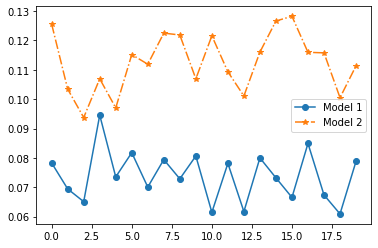

In [24]:
# Visualize the results

plt.plot(range(T), error_1, '-o', label='Model 1')
plt.plot(range(T), error_2, '-.*', label='Model 2')
plt.legend()

## One-hot encoding 

In the following codes, I use one-hot encoding to train a linear regression model.

In [26]:
# one-hot encoding
cat_all = ['sex', 'smoker', 'region']
df_medical = one_hot(df, cat_all)

# Dataset X, y
y = df_medical['charges'].to_numpy()
X = df_medical.drop(columns='charges').to_numpy()

# compute mse and relative squared errors
mse_model, rel_se_model = comput_test_error(X, y)

print(mse_model, rel_se_model)

27500042.13891181 0.08592979355323252
